In [1]:
import importlib
import pandas as pd
import analysis_functions as af
import analysis_functions_behv as af_b
import preprocess_behav2p as preprocess
importlib.reload(af_b)
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.decomposition import PCA
from scipy.signal import savgol_filter
from scipy import stats
from scipy.io import loadmat
from scipy.ndimage import uniform_filter1d
import os
import pickle
from matplotlib.animation import FuncAnimation
from scipy.ndimage import gaussian_filter1d
from scipy.stats import friedmanchisquare
from scipy.stats import wilcoxon
import pandas as pd
import openpyxl

Summary Plot

In [73]:
path = r"Y:\public\projects\SaEl_20220201_VIP\2pdata\LC\dreadds\LC_Dreadds_1\F_saline\behavior_data\all_data.pkl"

desktop_path = os.path.expanduser(path)
with open(desktop_path, 'rb') as f:
    loaded_data = pickle.load(f)

from pathlib import Path
p = Path(path)

In [70]:
data = {}
data[0] = loaded_data
ani = 0

In [ ]:
lick_onsets = data[ani]['aligned_data']['Lick'].to_numpy()
lick_rate = []
rolling_window_frames = 7
lick_count_rolling_sum = pd.Series(lick_onsets).rolling(window=rolling_window_frames,min_periods=1).sum()  # rolling sum over 7 frames
lick_rate = np.array(lick_count_rolling_sum)*7.5/rolling_window_frames # Convert to licks/sec (7.5 fps, 7 frames rolling window)

pupil_diameter = data[ani]['aligned_data']['pupil_diameter'].to_numpy()
pupil = (pupil_diameter-np.nanmedian(pupil_diameter))/np.nanmedian(pupil_diameter)
speed_absolute = data[ani]['aligned_data']['Speed_Absolute'].to_numpy()
speed = speed_absolute - np.percentile(speed_absolute,10)

In [72]:
# gratings and reward locations: grating 1 at 2.84, grating 2 at 5.95, grating 3 at 9.05, grating 4 at 12.15, reward at 14.6
gr4_loc = [np.mean(data[ani]['position'][np.array(data[ani]['grating_indices']['gr_4'])[:,20]]) for ani in data]
gr3_loc = [np.mean(data[ani]['position'][np.array(data[ani]['grating_indices']['gr_3'])[:,20]]) for ani in data]
gr2_loc = [np.mean(data[ani]['position'][np.array(data[ani]['grating_indices']['gr_2'])[:,20]]) for ani in data]
gr1_loc = [np.mean(data[ani]['position'][np.array(data[ani]['grating_indices']['gr_1'])[:,20]]) for ani in data]
reward_loc = [np.mean(data[ani]['position'][np.array(data[ani]['reward_indices'])[:,20]]) for ani in data]
print(np.mean(gr1_loc),np.mean(gr2_loc),np.mean(gr3_loc), np.mean(gr4_loc), np.mean(reward_loc))

KeyError: 'gr_4'

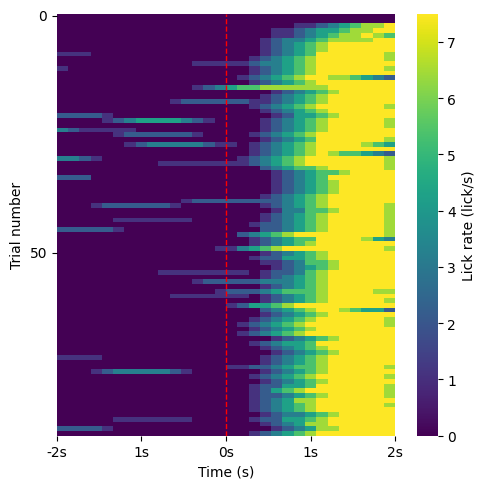

In [ ]:
bin_size = 1
bins = np.arange(0, 30 + bin_size, bin_size)
n_bins = len(bins) - 1
lick_rate_matrix = lick_rate[data[ani]['reward_indices']][:,5:35]

fig, ax = plt.subplots(figsize=(5, 5))

sns.heatmap(lick_rate_matrix, ax=ax, cmap='viridis', cbar_kws={'label': 'Lick rate (lick/s)'})
# set y-ticks every 50 trials (0, 50, 100, ...)
n_trials = lick_rate_matrix.shape[0]
y_ticks = np.arange(0, max(1, n_trials), 50)
y_labels = [str(int(y)) for y in y_ticks]
ax.set_yticks(y_ticks + 0.5)
ax.set_yticklabels(y_labels)
ax.set_ylabel('Trial number')

# set x-ticks every 7.5 bins -> every 1s 
n_bins = lick_rate_matrix.shape[1]
ax.set_xticks([0,7.5,15,22.5,30])
ax.set_xticklabels(['-2s','1s','0s','1s','2s'], rotation=0)
ax.set_xlabel('Time (s)')
ax.axvline(x=15, color='red', linestyle='--', linewidth=1)
plt.tight_layout()
plt.show()


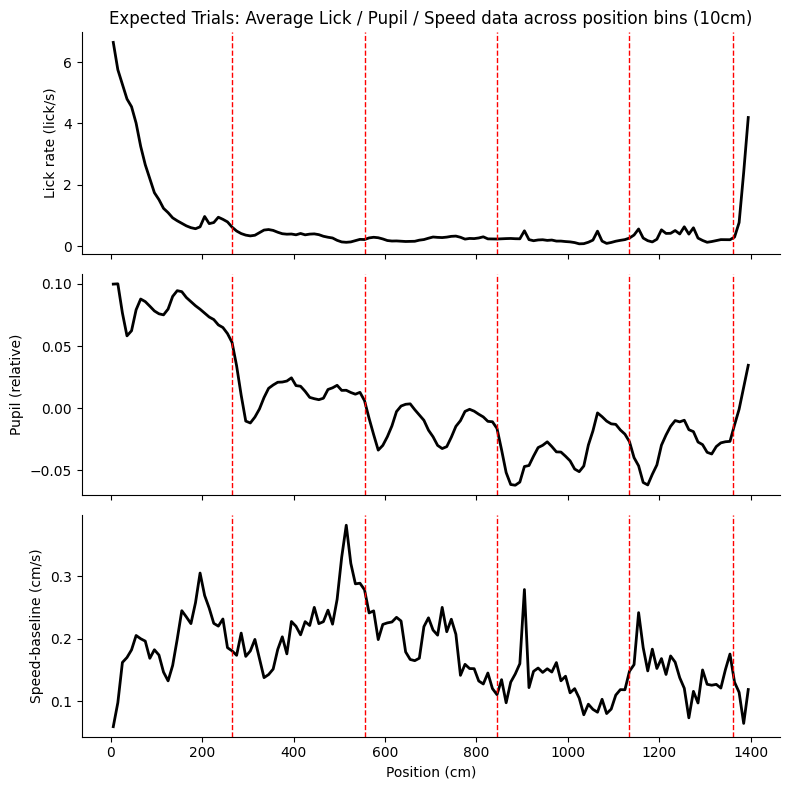

In [ ]:
bin_size = 10  # cm
bins = np.arange(0, 1400 + bin_size, bin_size)
n_bins = len(bins) - 1
bin_centers = (bins[:-1] + bins[1:]) / 2
animals = [0]

lick_matrix = np.zeros((len(animals), n_bins))
speed_matrix = np.zeros((len(animals), n_bins))
pupil_matrix = np.zeros((len(animals), n_bins))


for i,ani in enumerate(animals):
    # Predicted Trials Mask
    pred_mask = np.zeros(len(data[ani]['pupil']), dtype=bool)
    trial_starts = data[ani]['trial_start_indices']
    pred_trials = data[ani]['pred_trials']
    for t in pred_trials:
        start = trial_starts[t]
        if t < len(trial_starts) - 1:
            end = trial_starts[t+1]
        else:
            end = len(data[ani]['pupil']) 
        pred_mask[start:end] = True

    pos = data[ani]['position'] * 1400/15

    for b in range(n_bins):
        in_bin = (pos >= bins[b]) & (pos < bins[b+1]) & pred_mask
        if np.sum(in_bin) > 0:
            lick_matrix[i, b] = np.nanmean(lick_rate[in_bin])
            speed_matrix[i,b] = np.nanmean(speed[in_bin])
            pupil_matrix[i,b] = np.nanmean(pupil[in_bin])
        else:
            lick_matrix[i, b] = 0
            speed_matrix[i, b] = 0
            pupil_matrix[i, b] = 0

lick_trace = np.nanmean(lick_matrix, axis=0)
pupil_trace = np.nanmean(pupil_matrix, axis=0)
speed_trace = np.nanmean(speed_matrix, axis=0)

lick_smooth = gaussian_filter1d(lick_trace, sigma=0.5)
pupil_smooth = gaussian_filter1d(pupil_trace, sigma=0.5)
speed_smooth = gaussian_filter1d(speed_trace, sigma=0.5)

grat1_pos = 2.84 * 1400/15
grat2_pos = 5.95 * 1400/15
grat3_pos = 9.05 * 1400/15
grat4_pos = 12.15 * 1400/15
reward_pos = 14.6 * 1400/15

fig,axs = plt.subplots(3,1,figsize = (8,8), sharex=True)

# ----- Lick rate -----
axs[0].plot(bin_centers, lick_smooth, lw=2, color='black')
axs[0].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
axs[0].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
axs[0].axvline(x=grat3_pos, color='red', linestyle='--', linewidth=1)
axs[0].axvline(x=grat4_pos, color='red', linestyle='--', linewidth=1)
axs[0].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
axs[0].spines['right'].set_visible(False)
axs[0].spines['top'].set_visible(False)
# axs[0].spines['bottom'].set_visible(False)
axs[0].set_ylabel("Lick rate (lick/s)")
axs[0].set_title(f"Expected Trials: Average Lick / Pupil / Speed data across position bins ({bin_size}cm)")

# ----- Pupil -----
axs[1].plot(bin_centers, pupil_smooth, lw=2, color='black')
axs[1].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
axs[1].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
axs[1].axvline(x=grat3_pos, color='red', linestyle='--', linewidth=1)
axs[1].axvline(x=grat4_pos, color='red', linestyle='--', linewidth=1)
axs[1].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
axs[1].spines['right'].set_visible(False)
axs[1].spines['top'].set_visible(False)
# axs[1].spines['bottom'].set_visible(False)
axs[1].set_ylabel("Pupil (relative)")

# ----- Speed -----
axs[2].plot(bin_centers, speed_smooth, lw=2, color='black')
axs[2].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
axs[2].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
axs[2].axvline(x=grat3_pos, color='red', linestyle='--', linewidth=1)
axs[2].axvline(x=grat4_pos, color='red', linestyle='--', linewidth=1)
axs[2].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
axs[2].spines['right'].set_visible(False)
axs[2].spines['top'].set_visible(False)
axs[2].set_ylabel("Speed-baseline (cm/s)")
axs[2].set_xlabel("Position (cm)")

plt.tight_layout()
# plt.savefig("Behaviour across positions.svg", format="svg")
plt.show()

In [ ]:
pred_trials = np.unique(data[ani]['pred_trials'])
unpred_trials = data[ani]['unpred_trials']['gr_2']

# the predicted and unpredicted trials

In [ ]:
name = data[ani]['mouse_id'] + " " + p.parent.parent.name
print(name)

444_R AB1


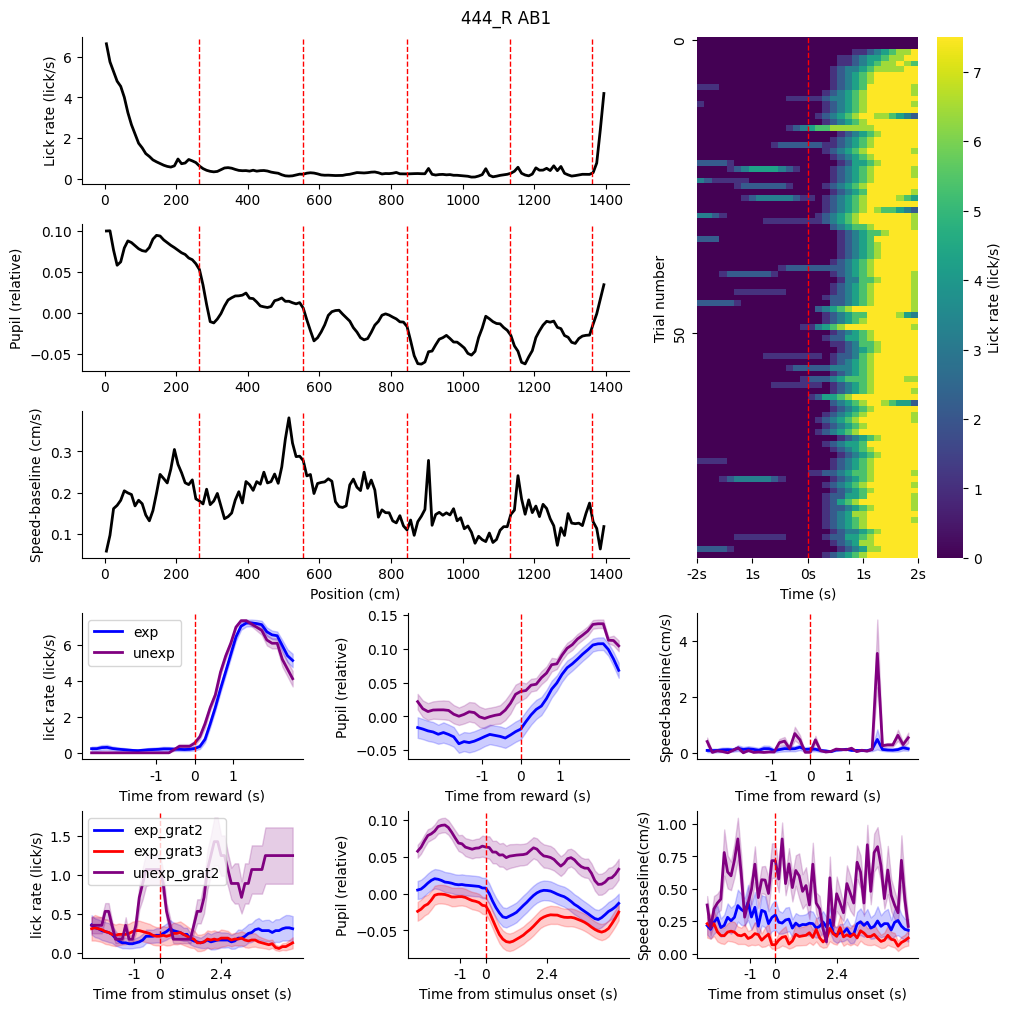

In [ ]:
mosaic = [    
    ["A", "A", "A", "A", "D", "D"],
    ["B", "B", "B", "B", "D", "D"],
    ["C", "C", "C", "C", "D", "D"],
    ["E", "E", "F", "F", "G", "G"],
    ["H", "H", "I", "I", "J", "J"],
    ]

fig, ax = plt.subplot_mosaic(mosaic, figsize=(10, 10), constrained_layout=True,)   # good default spacing

# ----- Lick rate -----
ax["A"].plot(bin_centers, lick_smooth, lw=2, color='black')
ax["A"].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
ax["A"].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
ax["A"].axvline(x=grat3_pos, color='red', linestyle='--', linewidth=1)
ax["A"].axvline(x=grat4_pos, color='red', linestyle='--', linewidth=1)
ax["A"].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
ax["A"].spines['right'].set_visible(False)
ax["A"].spines['top'].set_visible(False)
# axs[0].spines['bottom'].set_visible(False)
ax["A"].set_ylabel("Lick rate (lick/s)")

# ----- Pupil -----
ax["B"].plot(bin_centers, pupil_smooth, lw=2, color='black')
ax["B"].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
ax["B"].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
ax["B"].axvline(x=grat3_pos, color='red', linestyle='--', linewidth=1)
ax["B"].axvline(x=grat4_pos, color='red', linestyle='--', linewidth=1)
ax["B"].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
ax["B"].spines['right'].set_visible(False)
ax["B"].spines['top'].set_visible(False)
# axs[1].spines['bottom'].set_visible(False)
ax["B"].set_ylabel("Pupil (relative)")

# ----- Speed -----
ax["C"].plot(bin_centers, speed_smooth, lw=2, color='black')
ax["C"].axvline(x=grat1_pos, color='red', linestyle='--', linewidth=1)
ax["C"].axvline(x=grat2_pos, color='red', linestyle='--', linewidth=1)
ax["C"].axvline(x=grat3_pos, color='red', linestyle='--', linewidth=1)
ax["C"].axvline(x=grat4_pos, color='red', linestyle='--', linewidth=1)
ax["C"].axvline(x=reward_pos, color='red', linestyle='--', linewidth=1)
ax["C"].spines['right'].set_visible(False)
ax["C"].spines['top'].set_visible(False)
ax["C"].set_ylabel("Speed-baseline (cm/s)")
ax["C"].set_xlabel("Position (cm)")

sns.heatmap(lick_rate_matrix, ax=ax["D"], cmap='viridis', cbar_kws={'label': 'Lick rate (lick/s)'})
# set y-ticks every 50 trials (0, 50, 100, ...)
n_trials = lick_rate_matrix.shape[0]
y_ticks = np.arange(0, max(1, n_trials), 50)
y_labels = [str(int(y)) for y in y_ticks]
ax["D"].set_yticks(y_ticks + 0.5)
ax["D"].set_yticklabels(y_labels)
ax["D"].set_ylabel('Trial number')
# set x-ticks every 7.5 bins -> every 1s 
n_bins = lick_rate_matrix.shape[1]
ax["D"].set_xticks([0,7.5,15,22.5,30])
ax["D"].set_xticklabels(['-2s','1s','0s','1s','2s'], rotation=0)
ax["D"].set_xlabel('Time (s)')
ax["D"].axvline(x=15, color='red', linestyle='--', linewidth=1)

t_frames = np.array(data[ani]['reward_indices']).shape[1]
af.plot_shaded_error(ax["E"], np.arange(t_frames), lick_rate[data[ani]['reward_indices']], color='blue', label='exp', alpha=0.2,)
af.plot_shaded_error(ax["E"], np.arange(t_frames), lick_rate[data[ani]['reward_indices']][unpred_trials,:], color='purple', label='unexp', alpha=0.2,)
ax["E"].axvline(x=20, color='red', linestyle='--', linewidth=1)
ax["E"].set_ylabel('lick rate (lick/s)')
ax["E"].set_xlabel('Time from reward (s)')
ax["E"].set_xticks([12.5, 20, 27.5])
ax["E"].set_xticklabels(['-1', '0', '1'])
ax["E"].spines['right'].set_visible(False)
ax["E"].spines['top'].set_visible(False)

t_frames = np.array(data[ani]['reward_indices']).shape[1]
af.plot_shaded_error(ax["F"], np.arange(t_frames), pupil[data[ani]['reward_indices']], color='blue', label=None, alpha=0.2,)
af.plot_shaded_error(ax["F"], np.arange(t_frames), pupil[data[ani]['reward_indices']][unpred_trials,:], color='purple', label=None, alpha=0.2,)
ax["F"].axvline(x=20, color='red', linestyle='--', linewidth=1)
ax["F"].set_ylabel('Pupil (relative)')
ax["F"].set_xlabel('Time from reward (s)')
ax["F"].set_xticks([12.5, 20, 27.5])
ax["F"].set_xticklabels(['-1', '0', '1'])
ax["F"].spines['right'].set_visible(False)
ax["F"].spines['top'].set_visible(False)

t_frames = np.array(data[ani]['reward_indices']).shape[1]
af.plot_shaded_error(ax["G"], np.arange(t_frames), speed[data[ani]['reward_indices']], color='blue', label=None, alpha=0.2,)
af.plot_shaded_error(ax["G"], np.arange(t_frames), speed[data[ani]['reward_indices']][unpred_trials,:], color='purple', label=None, alpha=0.2,)
ax["G"].axvline(x=20, color='red', linestyle='--', linewidth=1)
ax["G"].set_ylabel('Speed-baseline(cm/s)')
ax["G"].set_xlabel('Time from reward (s)')
ax["G"].set_xticks([12.5, 20, 27.5])
ax["G"].set_xticklabels(['-1', '0', '1'])
ax["G"].spines['right'].set_visible(False)
ax["G"].spines['top'].set_visible(False)

t_frames = np.array(data[ani]['grating_indices']['gr_1']).shape[1]
af.plot_shaded_error(ax["H"], np.arange(t_frames), lick_rate[data[ani]['grating_indices']['gr_2']], color='blue', label='exp_grat2', alpha=0.2,)
af.plot_shaded_error(ax["H"], np.arange(t_frames), lick_rate[data[ani]['grating_indices']['gr_3']], color='red', label='exp_grat3', alpha=0.2,)
af.plot_shaded_error(ax["H"], np.arange(t_frames), lick_rate[data[ani]['grating_indices']['gr_2']][unpred_trials,:], color='purple', label='unexp_grat2', alpha=0.2,)
ax["H"].axvline(x=20, color='red', linestyle='--', linewidth=1)
ax["H"].set_ylabel('lick rate (lick/s)')
ax["H"].set_xlabel('Time from stimulus onset (s)')
ax["H"].set_xticks([12.5, 20, 38])
ax["H"].set_xticklabels(['-1', '0', '2.4'])
ax["H"].spines['right'].set_visible(False)
ax["H"].spines['top'].set_visible(False)

t_frames = np.array(data[ani]['grating_indices']['gr_1']).shape[1]
af.plot_shaded_error(ax["I"], np.arange(t_frames), pupil[data[ani]['grating_indices']['gr_2']], color='blue', label=None, alpha=0.2,)
af.plot_shaded_error(ax["I"], np.arange(t_frames), pupil[data[ani]['grating_indices']['gr_3']], color='red', label=None, alpha=0.2,)
af.plot_shaded_error(ax["I"], np.arange(t_frames), pupil[data[ani]['grating_indices']['gr_2']][unpred_trials,:], color='purple', label=None, alpha=0.2,)
ax["I"].axvline(x=20, color='red', linestyle='--', linewidth=1)
ax["I"].set_ylabel('Pupil (relative)')
ax["I"].set_xlabel('Time from stimulus onset (s)')
ax["I"].set_xticks([12.5, 20, 38])
ax["I"].set_xticklabels(['-1', '0', '2.4'])
ax["I"].spines['right'].set_visible(False)
ax["I"].spines['top'].set_visible(False)

t_frames = np.array(data[ani]['grating_indices']['gr_1']).shape[1]
af.plot_shaded_error(ax["J"], np.arange(t_frames), speed[data[ani]['grating_indices']['gr_2']], color='blue', label=None, alpha=0.2,)
af.plot_shaded_error(ax["J"], np.arange(t_frames), speed[data[ani]['grating_indices']['gr_3']], color='red', label=None, alpha=0.2,)
af.plot_shaded_error(ax["J"], np.arange(t_frames), speed[data[ani]['grating_indices']['gr_2']][unpred_trials,:], color='purple', label=None, alpha=0.2,)
ax["J"].axvline(x=20, color='red', linestyle='--', linewidth=1)
ax["J"].set_ylabel('Speed-baseline(cm/s)')
ax["J"].set_xlabel('Time from stimulus onset (s)')
ax["J"].set_xticks([12.5, 20, 38])
ax["J"].set_xticklabels(['-1', '0', '2.4'])
ax["J"].spines['right'].set_visible(False)
ax["J"].spines['top'].set_visible(False)

fig.suptitle(name)
fig.savefig(p.parent / "Behavior Summary.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
# bin_size = 20  # cm
# bins = np.arange(0, 1400 + bin_size, bin_size)
# n_bins = len(bins) - 1
# pred_trials = np.unique(data[ani]['pred_trials'])
# lick_rate_matrix = np.zeros((len(pred_trials), n_bins))  # trials are rows, bins are columns so (trials, bins)

# trial_starts = data[ani]['trial_start_indices']
# pos = data[ani]['position'] * 1400/15

# for i, trial in enumerate(pred_trials):
#     trial_mask = np.zeros(len(data[ani]['pupil']), dtype=bool)
#     start = trial_starts[trial]
#     if trial < len(trial_starts) - 1:
#         end = trial_starts[trial+1]
#     else:
#         end = len(data[ani]['pupil']) 
#     trial_mask[start:end] = True
#     for b in range(n_bins):
#         in_bin = (pos >= bins[b]) & (pos < bins[b+1]) & trial_mask
#         if np.sum(in_bin)>0:
#             lick_rate_matrix[i,b] = np.nanmean(lick_rate[in_bin])
#         else:
#             lick_rate_matrix[i,b] = 0

# lick_rate_matrix.shape

# fig, ax = plt.subplots(figsize=(10, 6))
# sns.heatmap(lick_rate_matrix, ax=ax, cmap='viridis', cbar_kws={'label': 'Lick rate (lick/s)'})

# # set y-ticks every 50 trials (0, 50, 100, ...)
# n_trials = lick_rate_matrix.shape[0]
# y_ticks = np.arange(0, max(1, n_trials), 50)
# y_labels = [str(int(y)) for y in y_ticks]
# ax.set_yticks(y_ticks + 0.5)
# ax.set_yticklabels(y_labels)
# ax.set_ylabel('Trial number')

# # set x-ticks every 5 bins -> every 200 cm 
# n_bins = lick_rate_matrix.shape[1]
# x_ticks = np.arange(0, n_bins, 10)
# x_labels = [f"{int(p*bin_size)}" for p in x_ticks]
# ax.set_xticks(x_ticks + 0.5)
# ax.set_xticklabels(x_labels, rotation=0)
# ax.set_xlabel('Position (cm)')
# plt.tight_layout()
# plt.show()